# t-SNE Visualization

Two plots:
1. **GNN** — graph embedding before domain adaptation (hook on `classifier` layer)
2. **CCSA** — graph embedding after domain adaptation (`GCN_CCSA` returns feature directly)
   - Target few-shot samples are marked in **gold** with the same family marker shape

In [5]:
import sys
sys.path.append("/home/tommy/Project/PCBSDA/ours")

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from torch_geometric.loader import DataLoader

from configs.gnn.baseline import get_gnn_config
from configs.ccsa.baseline import get_ccsa_config
from src.gnn.cross_architecture.models import GCN
from src.transfer_learning.ccsa.models import GCN_CCSA
from src.transfer_learning.ccsa.utils import prepare_ccsa_data

## Config

In [6]:
BASE_PATH = "/home/tommy/Project/PCBSDA"
EMBEDDING = "cbow"

GNN_CACHE_PATH      = f"{BASE_PATH}/ours/outputs/cache/gnn/{EMBEDDING}/gnn.pkl"
GNN_TEST_CACHE_PATH = f"{BASE_PATH}/ours/outputs/cache/gnn/{EMBEDDING}/gnn_test.pkl"
GNN_MODEL_PATH      = f"{BASE_PATH}/ours/outputs/models/gnn/{EMBEDDING}/gnn_model_classification_x86_64_seed_42.pt"

CCSA_MODEL_RS123    = f"{BASE_PATH}/ours/outputs/models/ccsa/{EMBEDDING}/ccsa_best_rs123.pt"
CCSA_MODEL_RS42     = f"{BASE_PATH}/ours/outputs/models/ccsa/{EMBEDDING}/ccsa_best_rs42.pt"

SAVE_DIR = Path(f"{BASE_PATH}/ours/outputs/plots/ccsa/t-sne")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MAX_PER_GROUP = 20   # max points per (domain, family) group to keep plot readable

FAMILIES = ['dnsamp', 'dofloo', 'gafgyt', 'kaiji', 'meterpreter', 'mirai', 'mobidash', 'tsunami']

DOMAIN_COLOR = {
    'source': '#2166AC',   # blue  — x86_64
    'target': '#D6604D',   # red   — ARM-32
}
FAMILY_MARKER = {
    'dnsamp':      'o',
    'dofloo':      's',
    'gafgyt':      '^',
    'kaiji':       'D',
    'meterpreter': 'P',
    'mirai':       'X',
    'mobidash':    'v',
    'tsunami':     'h',
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## Load Data

In [7]:
import pickle

# --- GNN cache (source = x86_64, target = ARM-32) ---
with open(GNN_CACHE_PATH, 'rb') as f:
    gnn_cache = pickle.load(f)
with open(GNN_TEST_CACHE_PATH, 'rb') as f:
    gnn_test_cache = pickle.load(f)

gnn_label_encoder = gnn_cache['label_encoder']
gnn_source = gnn_cache['train_graphs'] + gnn_cache['val_graphs']
gnn_target = gnn_test_cache['ARM-32']

print(f"GNN  source : {len(gnn_source)}  target : {len(gnn_target)}")
print(f"     classes: {list(gnn_label_encoder.classes_)}")

# --- CCSA split (rs=123) ---
ccsa_config = get_ccsa_config()

src_train_123, src_val_123, tgt_train_123, tgt_test_123, label_encoder, num_classes = prepare_ccsa_data(
    ccsa_config, random_state=123
)
ccsa_source_123 = src_train_123 + src_val_123
ccsa_target_123 = tgt_train_123 + tgt_test_123
fewshot_set_123 = set(range(len(tgt_train_123)))

print(f"\nCCSA rs=123  source : {len(ccsa_source_123)}  target : {len(ccsa_target_123)}  few-shot : {len(tgt_train_123)}")

# --- CCSA split (rs=42) ---
src_train_42, src_val_42, tgt_train_42, tgt_test_42, _, _ = prepare_ccsa_data(
    ccsa_config, random_state=42
)
ccsa_source_42 = src_train_42 + src_val_42
ccsa_target_42 = tgt_train_42 + tgt_test_42
fewshot_set_42 = set(range(len(tgt_train_42)))

print(f"CCSA rs=42   source : {len(ccsa_source_42)}  target : {len(ccsa_target_42)}  few-shot : {len(tgt_train_42)}")

GNN  source : 2081  target : 1866
     classes: [np.str_('dnsamp'), np.str_('dofloo'), np.str_('gafgyt'), np.str_('kaiji'), np.str_('meterpreter'), np.str_('mirai'), np.str_('mobidash'), np.str_('tsunami')]
載入 ['x86_64'] 資料: 2081 個樣本
已快取到: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_source.pkl
載入 ['ARM-32'] 資料: 1866 個樣本
已快取到: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_target.pkl

CCSA Data Summary:
  Source train: 1664, Source val: 417
  Target train (few-shot): 40, Target test: 1826
  Num classes: 8
  Source train distribution: {4: 240, 3: 195, 5: 240, 7: 240, 0: 166, 2: 240, 6: 240, 1: 103}
  Target train distribution: {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5}
  Target test distribution: {0: 90, 1: 295, 2: 295, 3: 129, 4: 132, 5: 295, 6: 295, 7: 295}

CCSA rs=123  source : 2081  target : 1866  few-shot : 40
載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_source.pkl
載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cb

## Helpers

In [8]:
def build_meta(source_graphs, target_graphs, fewshot_indices, label_encoder):
    """Build a list of dicts with domain / family / is_fewshot for every graph."""
    meta = []
    for g in source_graphs:
        meta.append({'domain': 'source', 'family': label_encoder.classes_[int(g.y)], 'fewshot': False})
    for i, g in enumerate(target_graphs):
        meta.append({'domain': 'target', 'family': label_encoder.classes_[int(g.y)], 'fewshot': i in fewshot_indices})
    return meta


@torch.no_grad()
def extract_gnn_embeddings(model, graphs, batch_size=256):
    """Extract pre-classifier embeddings from GCN (via forward hook)."""
    model.eval()
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feats, captured = [], []

    def _hook(module, inp, out):
        captured.append(inp[0].detach().cpu())

    handle = model.classifier.register_forward_hook(_hook)
    for batch in loader:
        batch = batch.to(DEVICE)
        captured.clear()
        model(batch.x, batch.edge_index, batch.batch)
        feats.append(captured[0].numpy())
    handle.remove()

    return np.concatenate(feats)


@torch.no_grad()
def extract_ccsa_embeddings(model, graphs, batch_size=256):
    """Extract graph-level features from GCN_CCSA (model returns (pred, feature))."""
    model.eval()
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feats = []
    for batch in loader:
        batch = batch.to(DEVICE)
        _, feature = model(batch.x, batch.edge_index, batch.batch)
        feats.append(feature.cpu().numpy())
    return np.concatenate(feats)


def run_tsne(embeddings, perplexity=30, seed=42):
    print(f"Running t-SNE on {embeddings.shape} ...")
    return TSNE(n_components=2, perplexity=perplexity, random_state=seed).fit_transform(embeddings)


def plot_tsne(coords, meta, title, save_path, show_fewshot=False, max_per_group=MAX_PER_GROUP):
    """
    Scatter plot: color = domain, marker = family.
    If show_fewshot=True, few-shot target samples are drawn in gold
    using their family marker (instead of the target red).
    """
    rng = np.random.RandomState(42)
    domains_arr = np.array([m['domain'] for m in meta])
    families_arr = np.array([m['family'] for m in meta])
    fewshot_arr = np.array([m['fewshot'] for m in meta])

    fig, ax = plt.subplots(figsize=(10, 7))

    for domain in ('source', 'target'):
        for fam in FAMILIES:
            mask = (domains_arr == domain) & (families_arr == fam)
            if show_fewshot and domain == 'target':
                mask &= ~fewshot_arr  # exclude few-shot — drawn separately below
            idx = np.where(mask)[0]

            if len(idx) == 0:
                continue
            if len(idx) > max_per_group:
                idx = rng.choice(idx, size=max_per_group, replace=False)

            ax.scatter(
                coords[idx, 0], coords[idx, 1],
                c=DOMAIN_COLOR[domain],
                marker=FAMILY_MARKER[fam],
                s=55, alpha=0.75,
                edgecolors='white', linewidths=0.4,
            )

    # Few-shot samples — gold, same family marker shape
    if show_fewshot:
        for fam in FAMILIES:
            idx = np.where(fewshot_arr & (families_arr == fam))[0]
            if len(idx) == 0:
                continue
            ax.scatter(
                coords[idx, 0], coords[idx, 1],
                c='#FFD700', marker=FAMILY_MARKER[fam],
                s=100, alpha=0.95,
                edgecolors='#555', linewidths=0.6,
                zorder=5,
            )

    # --- Legends ---
    domain_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markersize=9,
                   markerfacecolor=DOMAIN_COLOR[d],
                   label="Source (x86_64)" if d == 'source' else "Target (ARM-32)")
        for d in ('source', 'target')
    ]
    if show_fewshot:
        domain_handles.append(
            plt.Line2D([0], [0], marker='o', color='w', markersize=9,
                       markerfacecolor='#FFD700', markeredgecolor='#555',
                       label='Target few-shot')
        )
    family_handles = [
        plt.Line2D([0], [0], marker=FAMILY_MARKER[f], color='#555',
                   linestyle='None', markersize=9,
                   markerfacecolor='#555', label=f)
        for f in FAMILIES
    ]

    leg1 = ax.legend(handles=domain_handles, title='Domain',
                     loc='upper left', fontsize=9, title_fontsize=9,
                     framealpha=0.9, edgecolor='#ccc')
    ax.add_artist(leg1)
    ax.legend(handles=family_handles, title='Family',
              loc='upper right', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#ccc')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.grid(True, alpha=0.1, linestyle='--')
    ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")

## Plot 1 — GNN (no domain adaptation)

GNN model loaded.
Running t-SNE on (3947, 256) ...


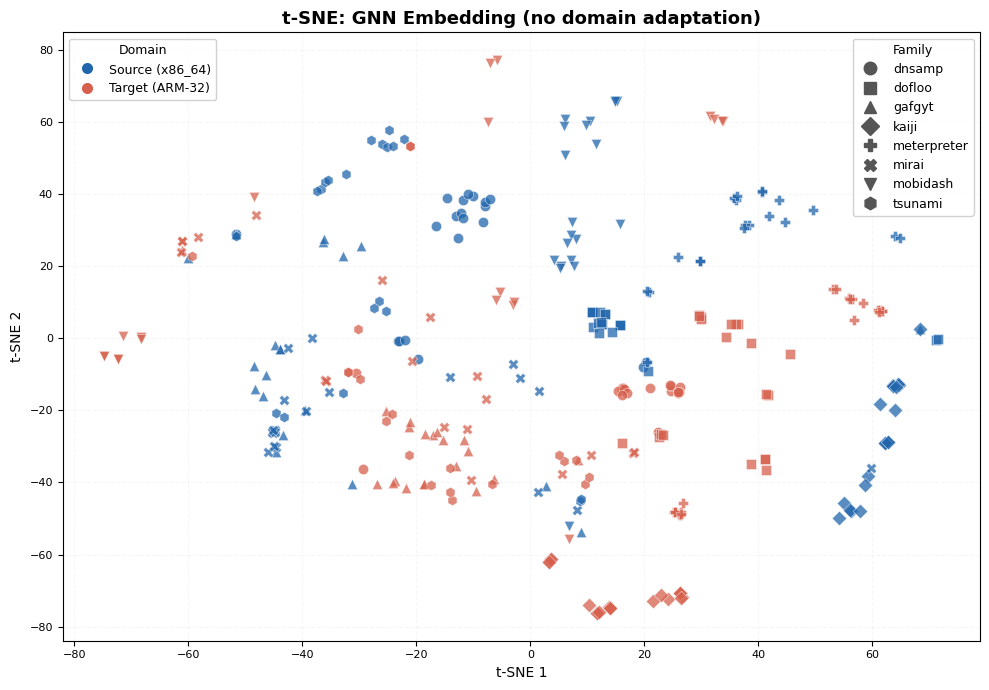

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_gnn.png


In [9]:
ckpt = torch.load(GNN_MODEL_PATH, map_location=DEVICE, weights_only=False)
cfg  = ckpt['config']
gnn_model = GCN(
    num_node_features=cfg['num_node_features'],
    hidden_channels=cfg['hidden_channels'],
    output_channels=cfg['output_channels'],
    num_classes=ckpt['num_classes'],
    num_layers=cfg['num_layers'],
    dropout=cfg['dropout'],
    pooling=cfg['pooling'],
).to(DEVICE)
gnn_model.load_state_dict(ckpt['model_state_dict'])
print("GNN model loaded.")

all_gnn_graphs = gnn_source + gnn_target
meta_gnn = build_meta(gnn_source, gnn_target, set(), gnn_label_encoder)

gnn_emb   = extract_gnn_embeddings(gnn_model, all_gnn_graphs)
gnn_coord = run_tsne(gnn_emb)

plot_tsne(
    gnn_coord, meta_gnn,
    title="t-SNE: GNN Embedding (no domain adaptation)",
    save_path=SAVE_DIR / "tsne_gnn.png",
    show_fewshot=False,
)

## Plot 1b — Raw Mean Pooling (no GNN, no domain adaptation)

Running t-SNE on (3947, 256) ...


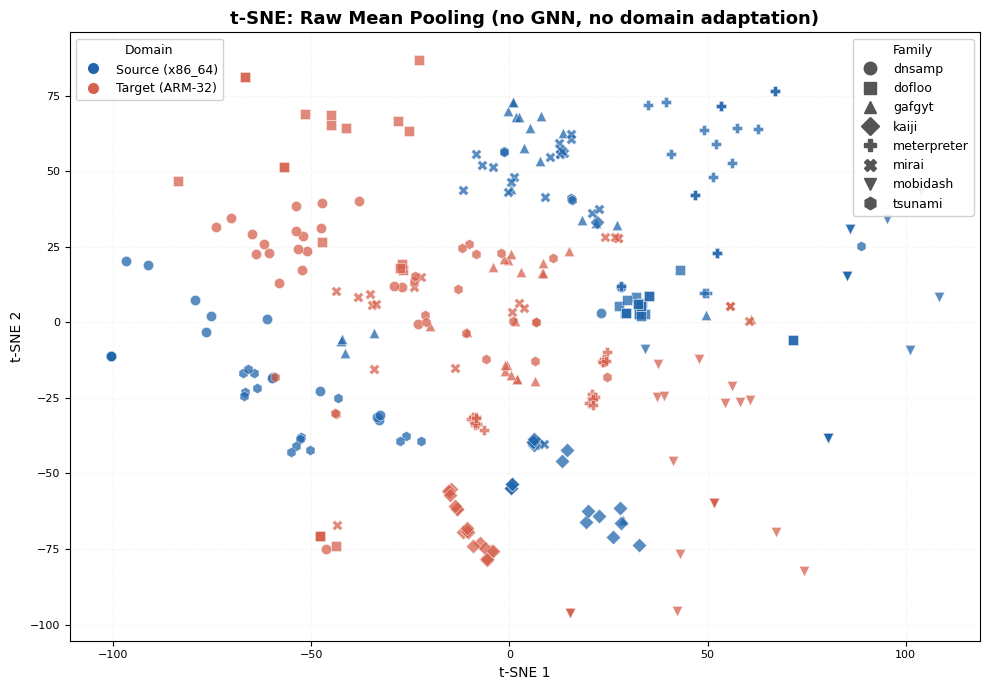

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_raw_mean_pool.png


In [10]:
@torch.no_grad()
def extract_raw_embeddings(graphs, batch_size=256):
    """Global mean pool over raw node features — no model involved."""
    from torch_geometric.nn import global_mean_pool
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feats = []
    for batch in loader:
        pooled = global_mean_pool(batch.x, batch.batch)
        feats.append(pooled.cpu().numpy())
    return np.concatenate(feats)


raw_mean_emb   = extract_raw_embeddings(all_gnn_graphs)
raw_mean_coord = run_tsne(raw_mean_emb)

plot_tsne(
    raw_mean_coord, meta_gnn,
    title="t-SNE: Raw Mean Pooling (no GNN, no domain adaptation)",
    save_path=SAVE_DIR / "tsne_raw_mean_pool.png",
    show_fewshot=False,
)

## Plot 2 — CCSA (after domain adaptation)

CCSA rs=123 model loaded.
Running t-SNE on (3947, 256) ...


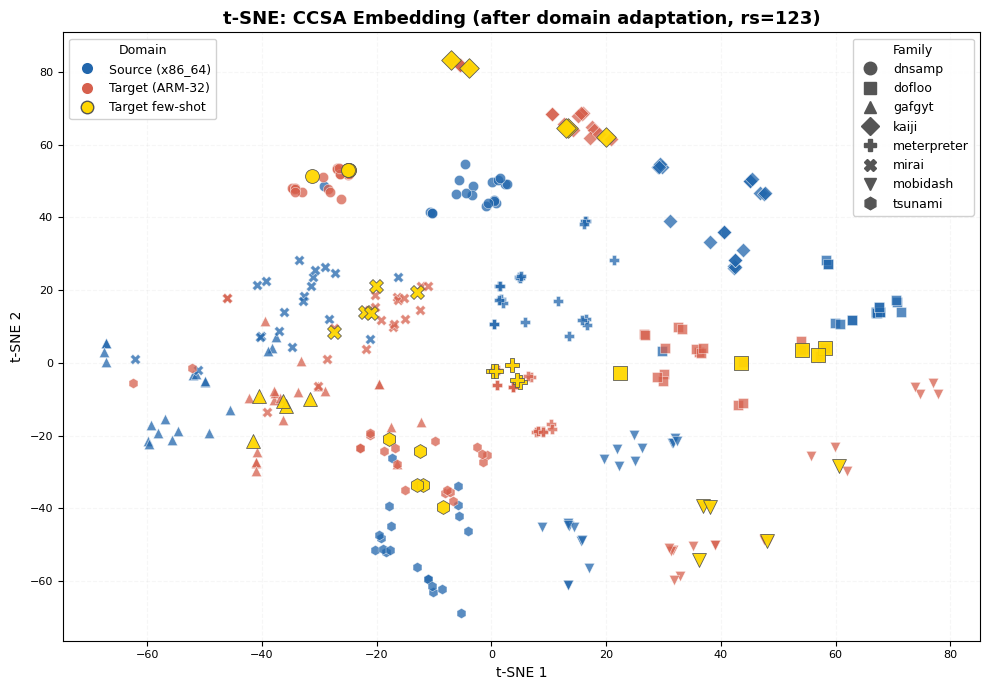

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_ccsa_rs123.png


In [11]:
ccsa_state_123 = torch.load(CCSA_MODEL_RS123, map_location=DEVICE, weights_only=False)
ccsa_model_123 = GCN_CCSA(
    num_node_features=ccsa_config['num_node_features'],
    hidden_channels=ccsa_config['hidden_channels'],
    output_channels=ccsa_config['output_channels'],
    num_classes=num_classes,
    num_layers=ccsa_config['num_layers'],
    dropout=ccsa_config['dropout'],
    pooling=ccsa_config['pooling'],
).to(DEVICE)
ccsa_model_123.load_state_dict(ccsa_state_123)
print("CCSA rs=123 model loaded.")

all_ccsa_graphs_123 = ccsa_source_123 + ccsa_target_123
meta_ccsa_123 = build_meta(ccsa_source_123, ccsa_target_123, fewshot_set_123, label_encoder)

ccsa_emb_123   = extract_ccsa_embeddings(ccsa_model_123, all_ccsa_graphs_123)
ccsa_coord_123 = run_tsne(ccsa_emb_123)

plot_tsne(
    ccsa_coord_123, meta_ccsa_123,
    title="t-SNE: CCSA Embedding (after domain adaptation, rs=123)",
    save_path=SAVE_DIR / "tsne_ccsa_rs123.png",
    show_fewshot=True,
)

## Plot 3 — CCSA (rs=42)

In [12]:
@torch.no_grad()
def extract_raw_embeddings(graphs, batch_size=256):
    """Global mean pool over raw node features — no model involved."""
    from torch_geometric.nn import global_mean_pool
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feats = []
    for batch in loader:
        pooled = global_mean_pool(batch.x, batch.batch)
        feats.append(pooled.cpu().numpy())
    return np.concatenate(feats)


def plot_fewshot_comparison(coords, meta, rs_label, save_path):
    """
    One plot per random_state.
    All target points drawn in red (normal) or gold (few-shot), source in blue.
    Marker = family shape.
    """
    rng = np.random.RandomState(42)
    domains_arr  = np.array([m['domain']  for m in meta])
    families_arr = np.array([m['family']  for m in meta])
    fewshot_arr  = np.array([m['fewshot'] for m in meta])

    fig, ax = plt.subplots(figsize=(10, 7))

    # source (blue, low alpha — background context)
    for fam in FAMILIES:
        idx = np.where((domains_arr == 'source') & (families_arr == fam))[0]
        if len(idx) == 0:
            continue
        if len(idx) > MAX_PER_GROUP:
            idx = rng.choice(idx, size=MAX_PER_GROUP, replace=False)
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=DOMAIN_COLOR['source'], marker=FAMILY_MARKER[fam],
                   s=40, alpha=0.3, edgecolors='none')

    # target non-fewshot (red, medium)
    for fam in FAMILIES:
        idx = np.where((domains_arr == 'target') & (families_arr == fam) & ~fewshot_arr)[0]
        if len(idx) == 0:
            continue
        if len(idx) > MAX_PER_GROUP:
            idx = rng.choice(idx, size=MAX_PER_GROUP, replace=False)
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=DOMAIN_COLOR['target'], marker=FAMILY_MARKER[fam],
                   s=55, alpha=0.55, edgecolors='white', linewidths=0.3)

    # few-shot (gold, large, on top)
    for fam in FAMILIES:
        idx = np.where((families_arr == fam) & fewshot_arr)[0]
        if len(idx) == 0:
            continue
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c='#FFD700', marker=FAMILY_MARKER[fam],
                   s=130, alpha=1.0, edgecolors='#333', linewidths=0.8,
                   zorder=5, label=fam)

    # Legend
    domain_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                   markerfacecolor=DOMAIN_COLOR['source'], alpha=0.4, label='Source (x86_64)'),
        plt.Line2D([0], [0], marker='o', color='w', markersize=8,
                   markerfacecolor=DOMAIN_COLOR['target'], label='Target (ARM-32)'),
        plt.Line2D([0], [0], marker='o', color='w', markersize=10,
                   markerfacecolor='#FFD700', markeredgecolor='#333', label=f'Few-shot ({rs_label})'),
    ]
    family_handles = [
        plt.Line2D([0], [0], marker=FAMILY_MARKER[f], color='#555',
                   linestyle='None', markersize=9, markerfacecolor='#555', label=f)
        for f in FAMILIES
    ]
    leg1 = ax.legend(handles=domain_handles, title='Domain',
                     loc='upper left', fontsize=9, title_fontsize=9,
                     framealpha=0.9, edgecolor='#ccc')
    ax.add_artist(leg1)
    ax.legend(handles=family_handles, title='Family',
              loc='upper right', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#ccc')

    ax.set_title(f"Raw Embedding — Few-Shot Position ({rs_label})\n"
                 f"Gold = selected few-shot samples (before DA)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.grid(True, alpha=0.1, linestyle='--')
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")


# --- Build a shared raw embedding space for ALL graphs ---
# Use CCSA rs=123 split as the base (same total graphs, only few-shot indices differ)
all_graphs_raw = ccsa_source_123 + ccsa_target_123
raw_emb   = extract_raw_embeddings(all_graphs_raw)
raw_coord = run_tsne(raw_emb)
print(f"Raw embedding t-SNE done: {raw_coord.shape}")

Running t-SNE on (3947, 256) ...
Raw embedding t-SNE done: (3947, 2)


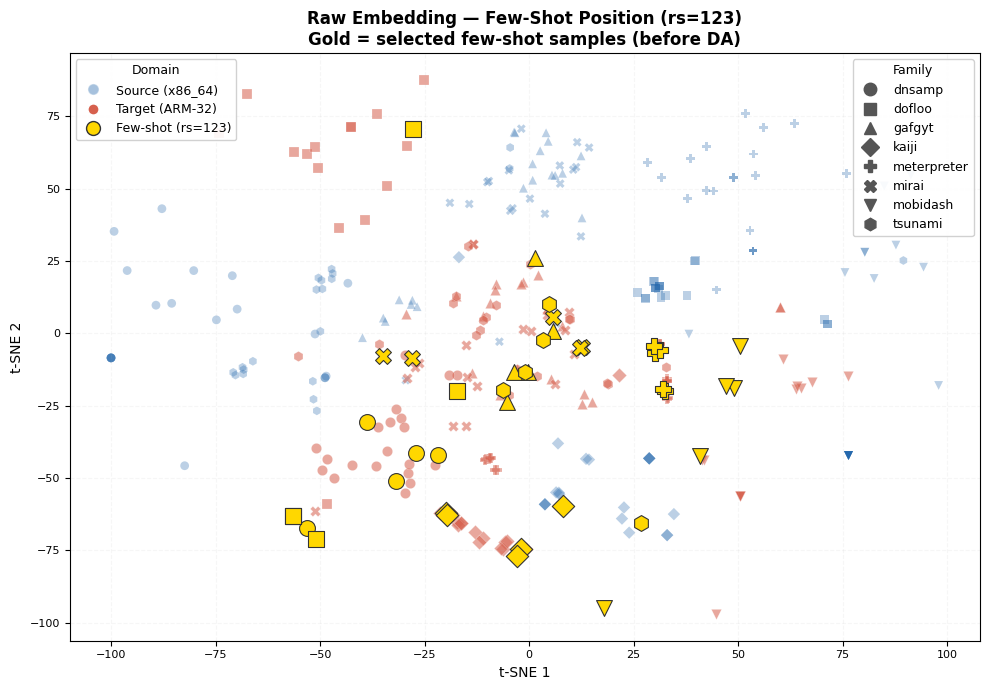

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_fewshot_raw_rs123.png
Running t-SNE on (3947, 256) ...


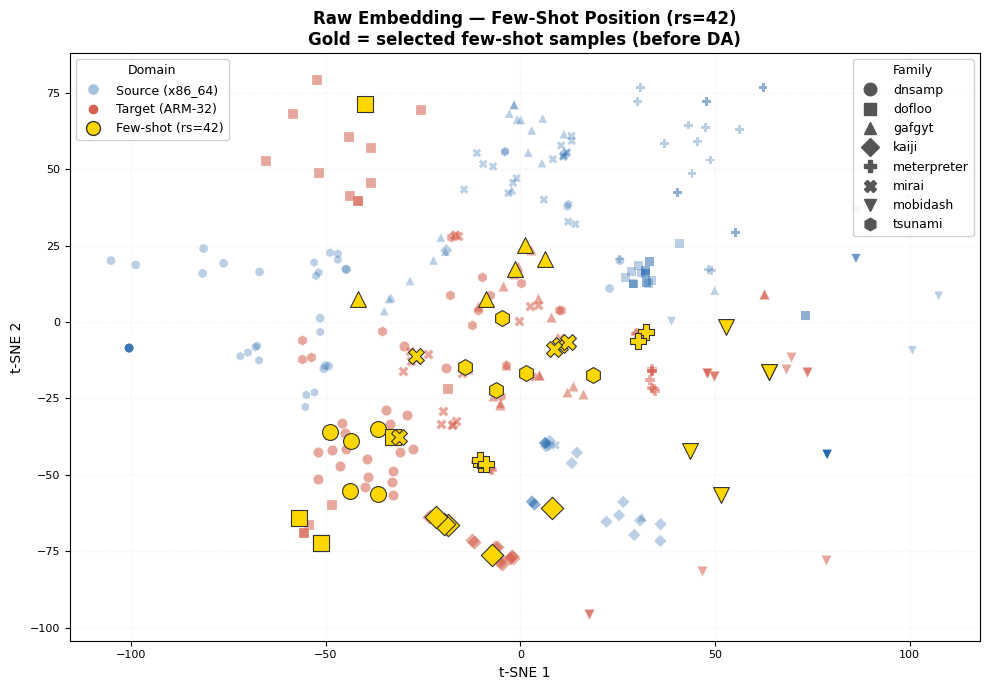

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_fewshot_raw_rs42.png


In [13]:
n_source = len(ccsa_source_123)

# rs=123 — few-shot indices are within the target portion
meta_raw_123 = build_meta(ccsa_source_123, ccsa_target_123, fewshot_set_123, label_encoder)
plot_fewshot_comparison(
    raw_coord, meta_raw_123,
    rs_label='rs=123',
    save_path=SAVE_DIR / "tsne_fewshot_raw_rs123.png",
)

# rs=42 — same graphs, different few-shot indices
# target graphs are identical (ccsa_target_123 == ccsa_target_42 in content, same split base)
# but fewshot_set_42 marks different indices as few-shot
meta_raw_42 = build_meta(ccsa_source_42, ccsa_target_42, fewshot_set_42, label_encoder)

# ccsa_target_42 may differ slightly from ccsa_target_123 due to re-split
# recompute raw embeddings for rs=42 graphs
all_graphs_raw_42 = ccsa_source_42 + ccsa_target_42
raw_emb_42   = extract_raw_embeddings(all_graphs_raw_42)
raw_coord_42 = run_tsne(raw_emb_42)

plot_fewshot_comparison(
    raw_coord_42, meta_raw_42,
    rs_label='rs=42',
    save_path=SAVE_DIR / "tsne_fewshot_raw_rs42.png",
)

## Plot 4 — Few-Shot Sample Quality (raw embedding, before DA)

Compare rs=123 vs rs=42 few-shot positions **before any model training**.
If rs=42 few-shot samples land on cluster edges or overlap with wrong families,
that explains the lower performance — the model received less representative supervision.

CCSA rs=42 model loaded.
Running t-SNE on (3947, 256) ...


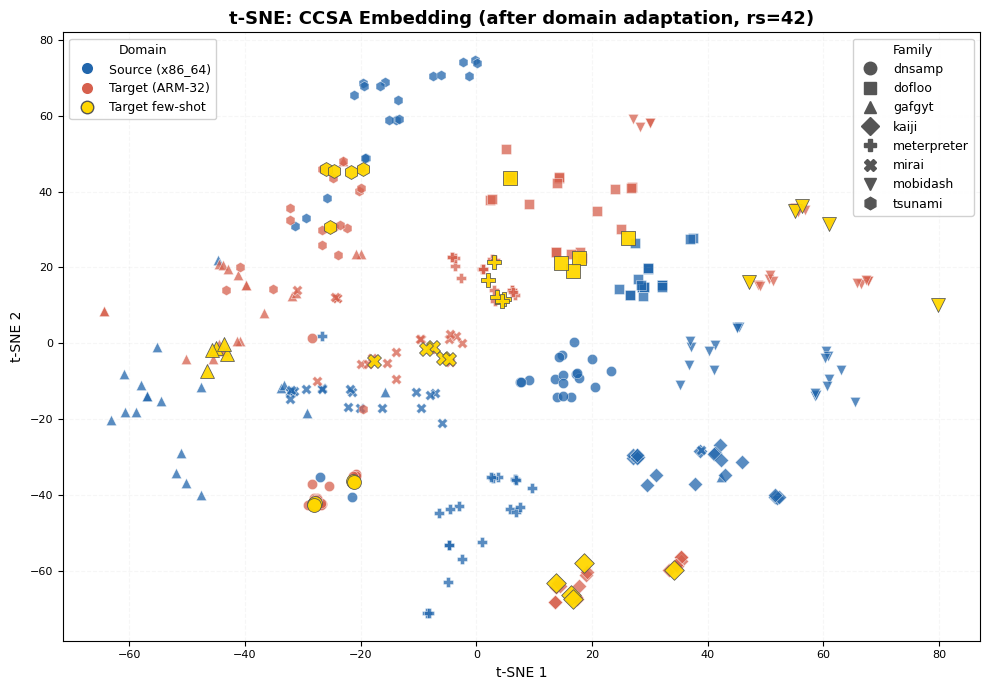

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/ccsa/t-sne/tsne_ccsa_rs42.png


: 

In [ ]:
ccsa_state_42 = torch.load(CCSA_MODEL_RS42, map_location=DEVICE, weights_only=False)
ccsa_model_42 = GCN_CCSA(
    num_node_features=ccsa_config['num_node_features'],
    hidden_channels=ccsa_config['hidden_channels'],
    output_channels=ccsa_config['output_channels'],
    num_classes=num_classes,
    num_layers=ccsa_config['num_layers'],
    dropout=ccsa_config['dropout'],
    pooling=ccsa_config['pooling'],
).to(DEVICE)
ccsa_model_42.load_state_dict(ccsa_state_42)
print("CCSA rs=42 model loaded.")

all_ccsa_graphs_42 = ccsa_source_42 + ccsa_target_42
meta_ccsa_42 = build_meta(ccsa_source_42, ccsa_target_42, fewshot_set_42, label_encoder)

ccsa_emb_42   = extract_ccsa_embeddings(ccsa_model_42, all_ccsa_graphs_42)
ccsa_coord_42 = run_tsne(ccsa_emb_42)

plot_tsne(
    ccsa_coord_42, meta_ccsa_42,
    title="t-SNE: CCSA Embedding (after domain adaptation, rs=42)",
    save_path=SAVE_DIR / "tsne_ccsa_rs42.png",
    show_fewshot=True,
)